<a href="https://colab.research.google.com/github/hazywarden313/First_successful_neural_network/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.7312480160537063
0.9398220614681078
0.9333394368896453
0.870905062485606
0.6965667789165283
0.6940436501663181
0.6010562576437877
0.5350831969214129
0.556665442299168
0.5991029624481632
0.5216687970999636
0.6375316324807381
0.5286926599232743
0.3584851634081049
0.4889692447045617
0.5903980978360833


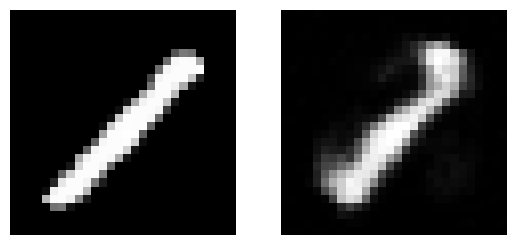

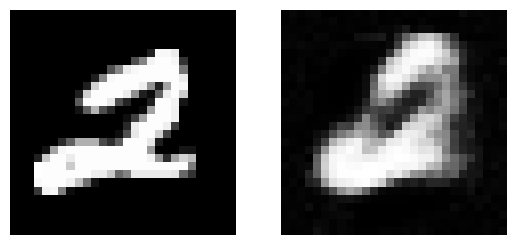

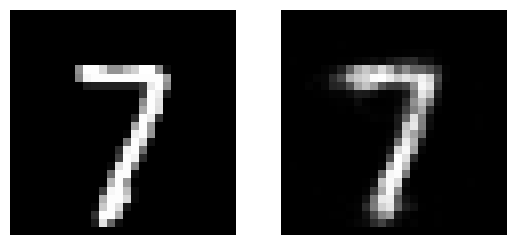

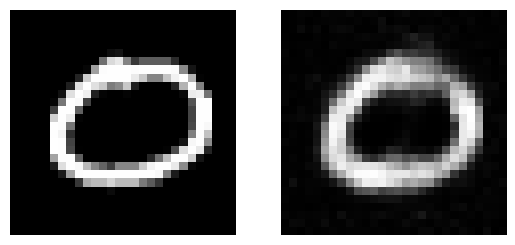

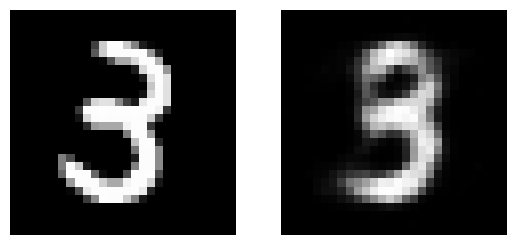

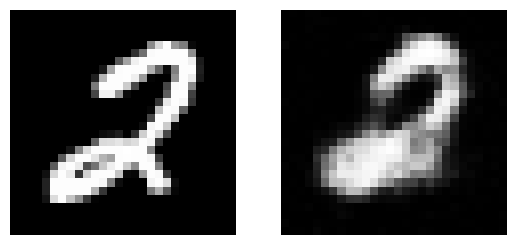

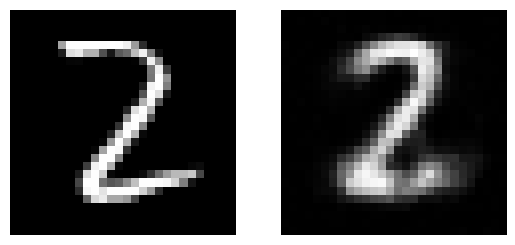

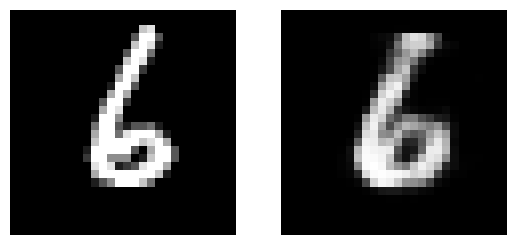

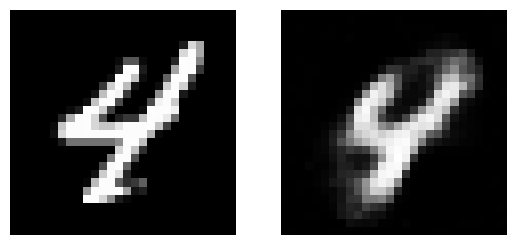

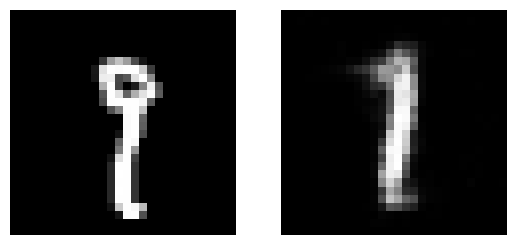

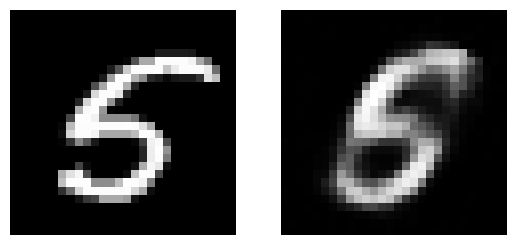

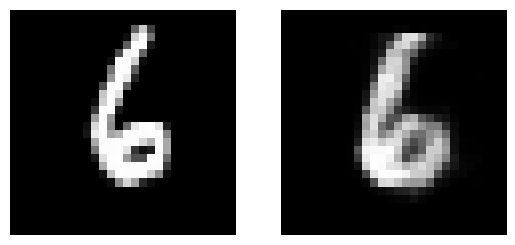

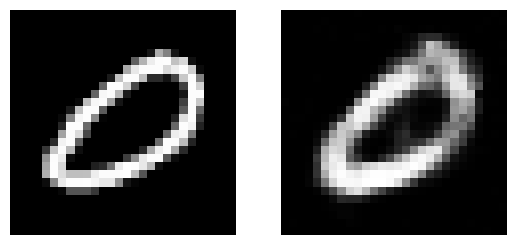

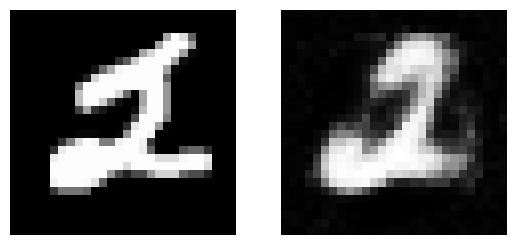

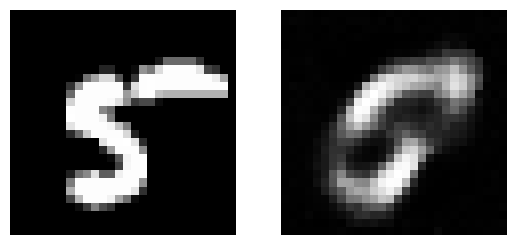

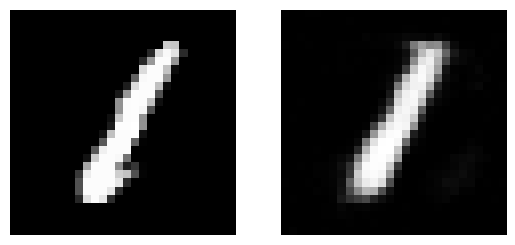

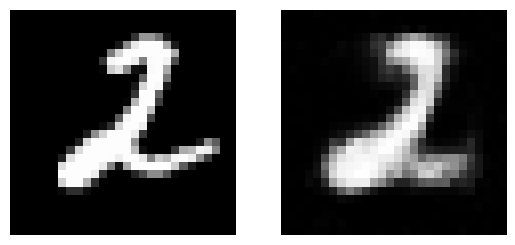

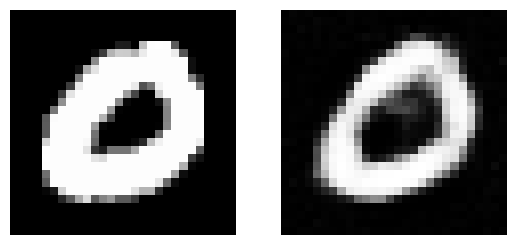

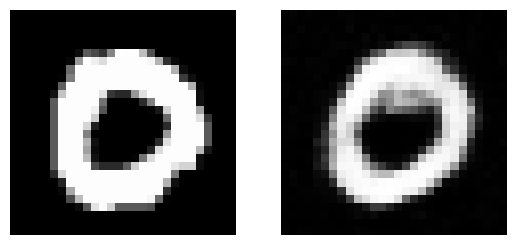

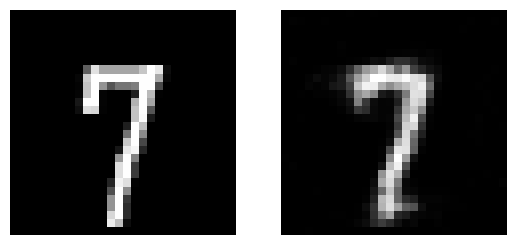

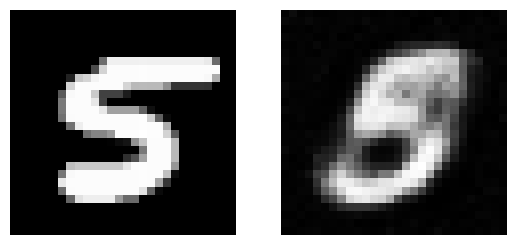

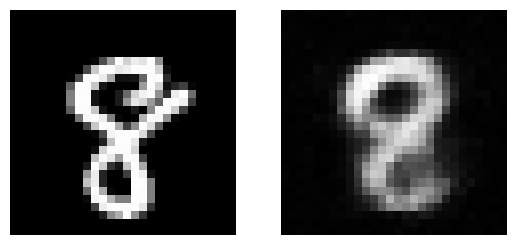

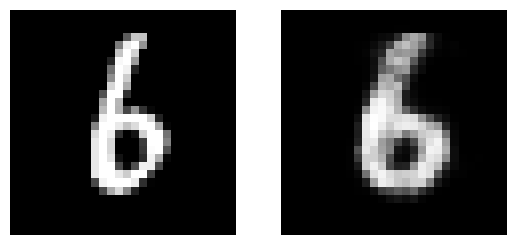

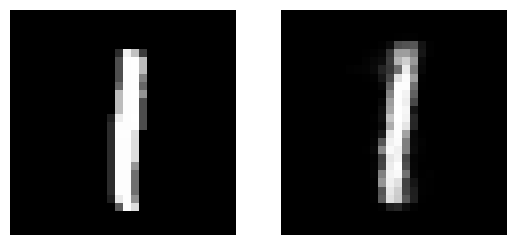

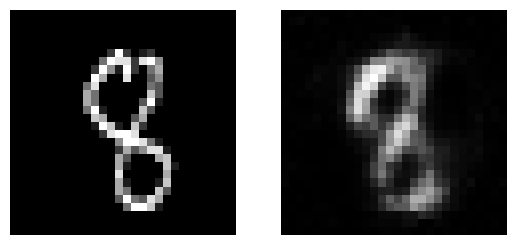

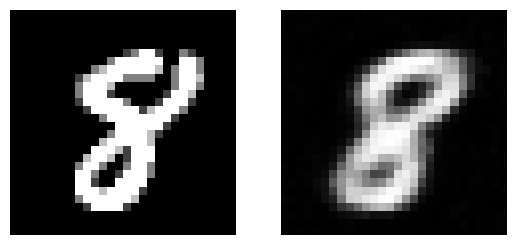

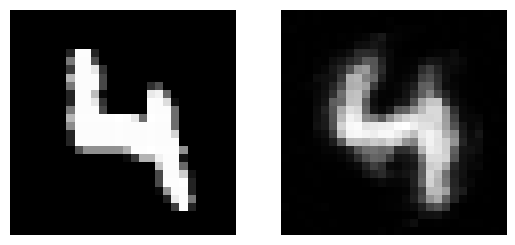

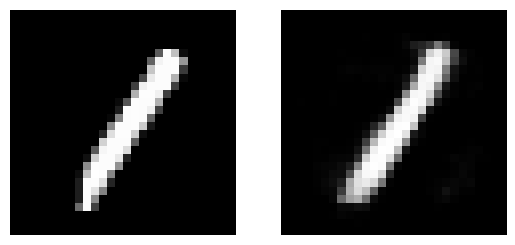

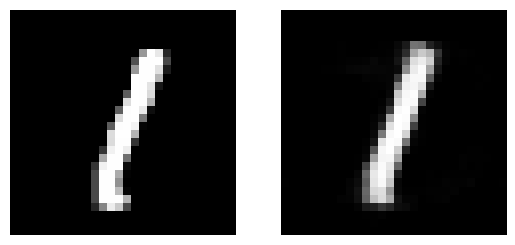

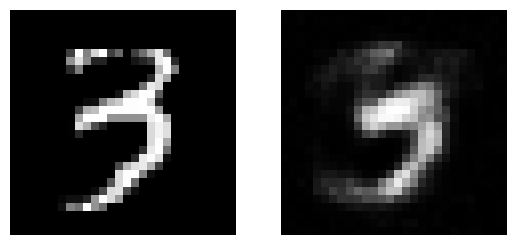

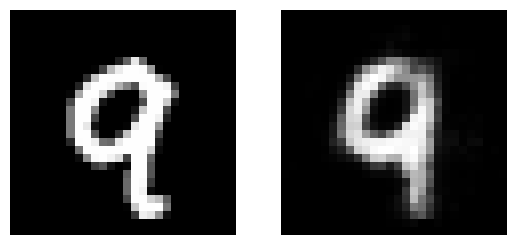

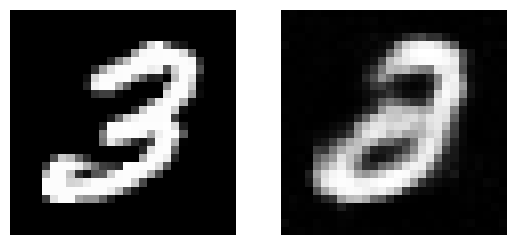

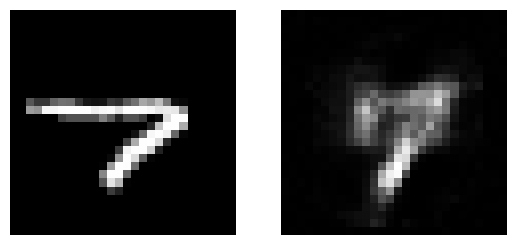

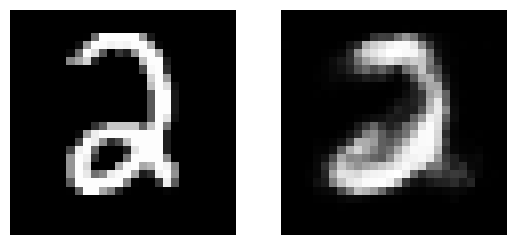

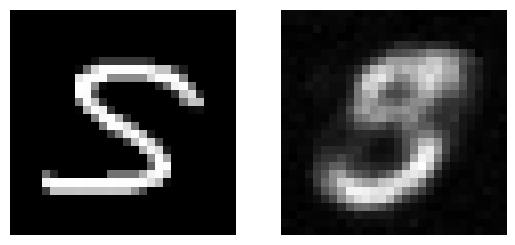

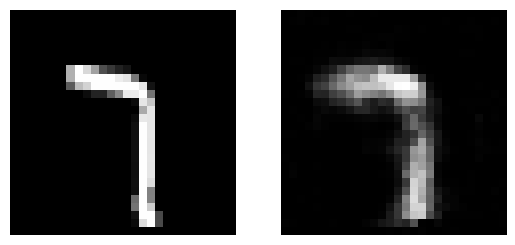

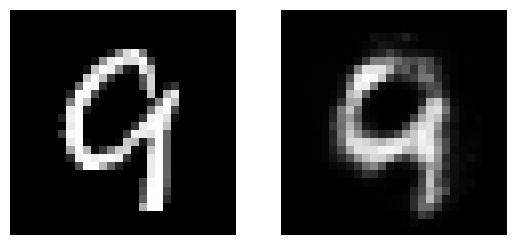

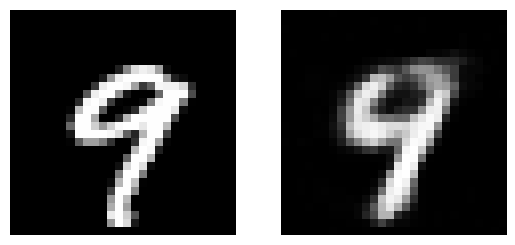

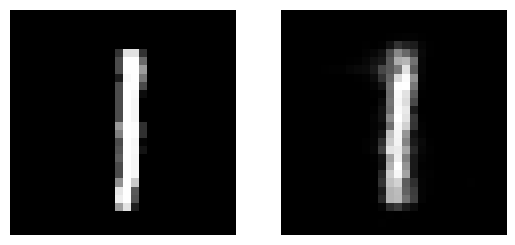

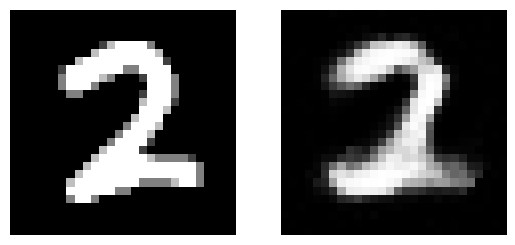

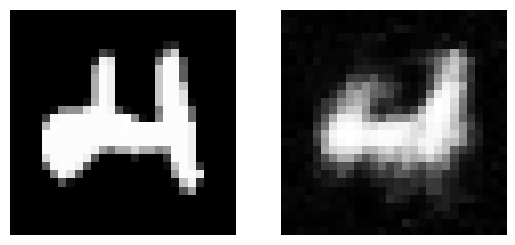

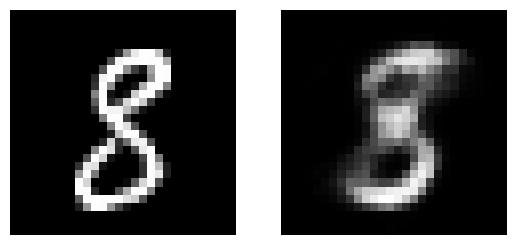

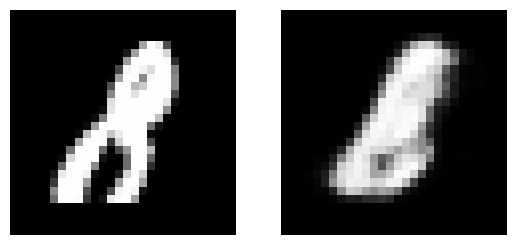

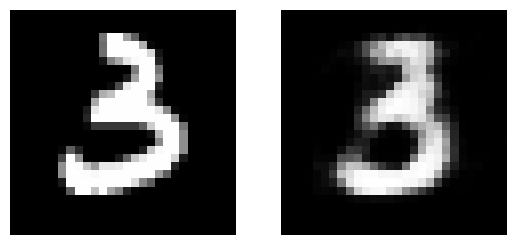

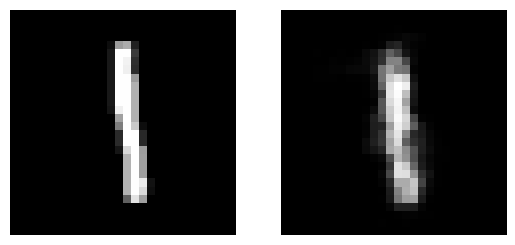

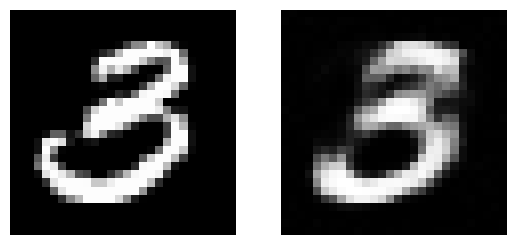

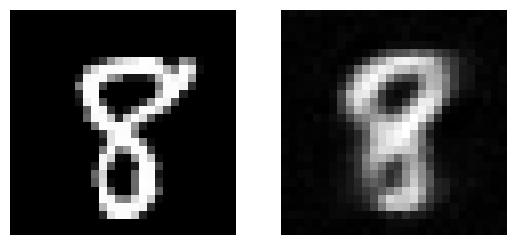

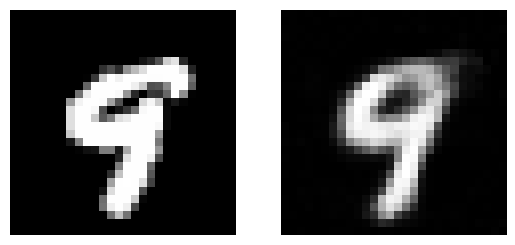

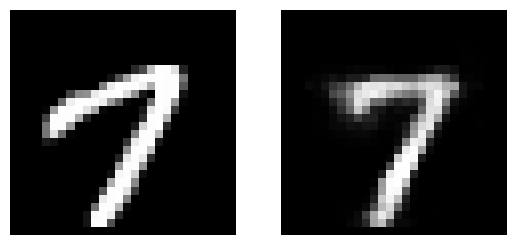

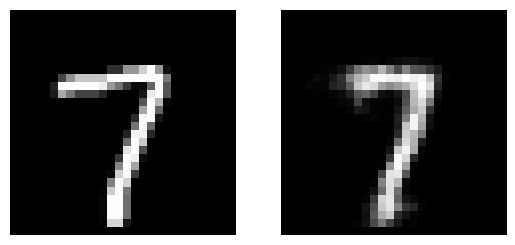

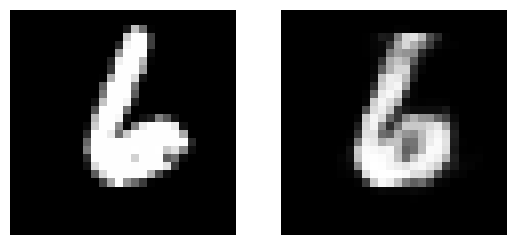

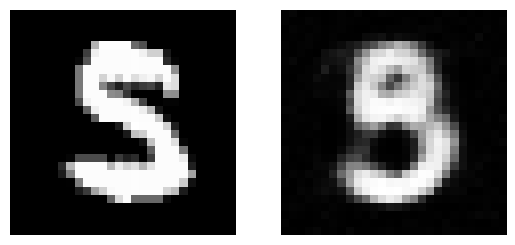

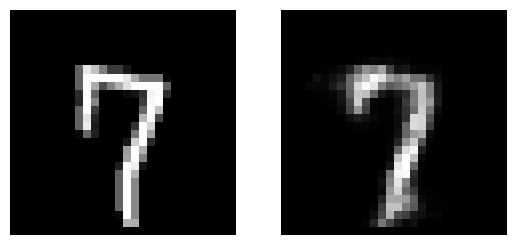

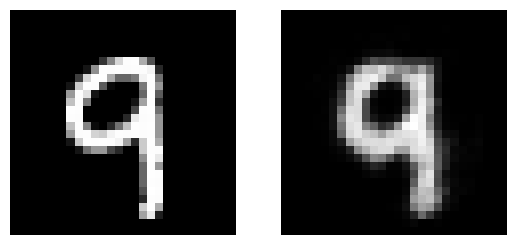

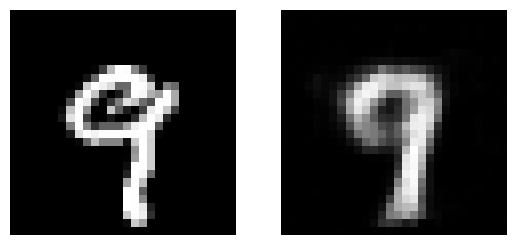

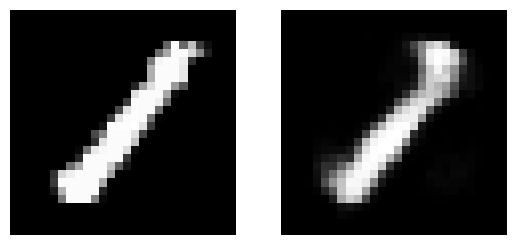

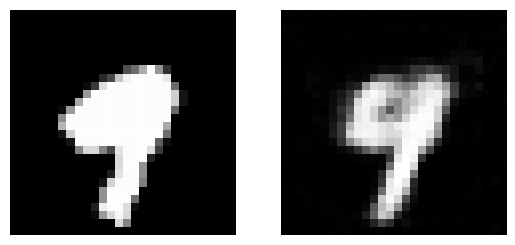

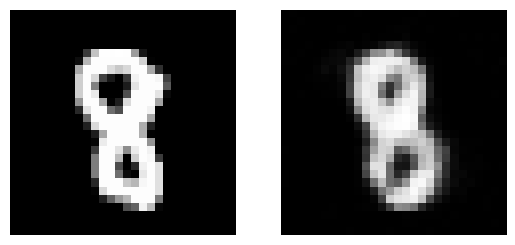

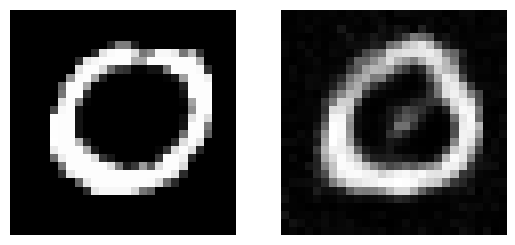

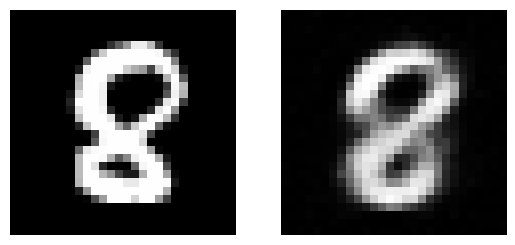

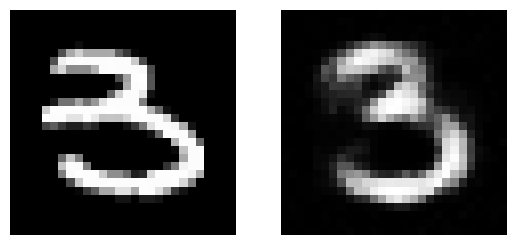

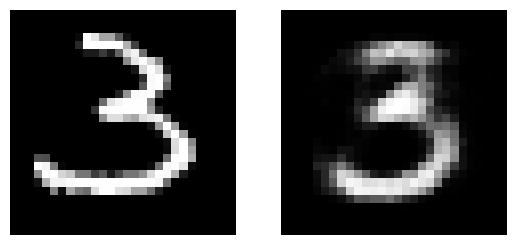

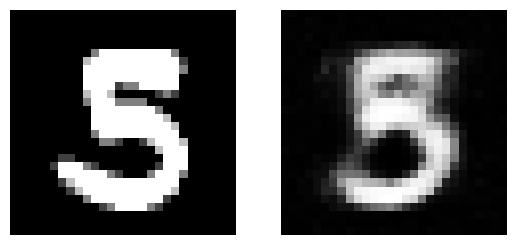

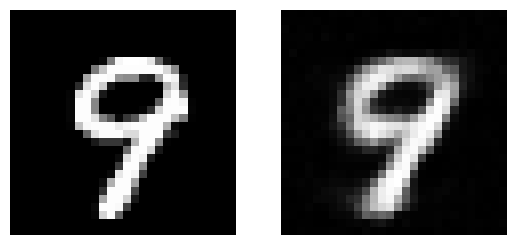

In [ ]:
#import libraries
import matplotlib.pyplot as plt
import numpy as np
import random

#import dataset
import tensorflow_datasets as tfds
from tensorflow.keras.datasets import mnist
(xtrain,ytrain), (xtest,ytest) = mnist.load_data()



#settings
shape = [784,64,16,64,784]
learn = 0.1 #learning rate
noise = 0.1 #noise strength
batch = 16 #batch size
count = 1600 #batch count

#shape
depth = len(shape) - 1
nn = [[None for _ in range(6)] for _ in range(depth)]

#network
for i in range(depth):
  nn[i][0] = (np.random.rand(shape[i+1], shape[i]) - 0.5) * np.sqrt(2.0 / shape[i]) #weight
  nn[i][1] = np.zeros((shape[i+1],shape[i])) #weight gradient
  nn[i][2] = np.zeros((shape[i+1],)) #bias
  nn[i][3] = np.zeros((shape[i+1],)) #bias gradient
  nn[i][4] = None #pre-activation
  nn[i][5] = None #activation



#gradient accumulation
def accumulate(nn, depth, error, xtrain):

  #input
  l0 = xtrain[random.randint(0, len(xtrain) - 1)].flatten() / 255
  act = l0 + np.random.normal(0, noise, shape[0])

  #beginning
  nn[0][4] = nn[0][0] @ act + nn[0][2] #layer math
  nn[0][5] = (nn[0][4] * 1.1 + np.abs(nn[0][4])) / 2.1 #leaky relu

  #middle
  for i in range(1, depth - 1):
    nn[i][4] = nn[i][0] @ nn[i-1][5] + nn[i][2] #layer math
    nn[i][5] = (nn[i][4] * 1.1 + np.abs(nn[i][4]))/2.1 #leaky relu

  #end
  nn[-1][4] = nn[-1][0] @ nn[-2][5] + nn[-1][2] #layer math
  nn[-1][5] = 1 / (1 + np.exp(-nn[-1][4])) #sigmoid

  #error
  r = l0 - nn[-1][5]
  error += np.mean(r**2) #mean squared error

  #end
  r *= nn[-1][5] * (1.0 - nn[-1][5]) #error math
  nn[-1][1] += np.outer(r, nn[-2][5]) #weight gradient
  nn[-1][3] += r #bias gradient

  #middle
  for i in range(depth - 2, 0, -1):
    r = nn[i+1][0].T @ r * np.where(nn[i][4] > 0, 1.0, 0.1 / 2.1) #error math
    nn[i][1] += np.outer(r, nn[i-1][5]) #weight gradient
    nn[i][3] += r #bias gradient

  #beginning
  r = nn[1][0].T @ r * np.where(nn[0][4] > 0, 1.0, 0.1 / 2.1) #error math
  nn[0][1] += np.outer(r, act) #weight gradient
  nn[0][3] += r #bias gradient

  return nn, error



#update
def update(nn, depth, learn):
  for i in range(depth):

    #update parameters
    nn[i][0] += nn[i][1] / batch * learn
    nn[i][2] += nn[i][3] / batch * learn

    #clear gradients
    nn[i][1].fill(0.0)
    nn[i][3].fill(0.0)

  return nn



#training
for i in range(count):

  #batch
  error = 0
  for _ in range(batch):
    nn, error = accumulate(nn, depth, error, xtrain)

  #update
  nn = update(nn, depth, learn)

  #debug
  if i % 100 == 0:
    print(error)



#test
def test(nn, depth, xtest):

  #input
  l0 = xtest[random.randint(0, len(xtest) - 1)].flatten() / 255
  act = l0 + np.random.normal(0, noise, shape[0])

  #beginning
  nn[0][4] = nn[0][0] @ act + nn[0][2] #layer math
  nn[0][5] = (nn[0][4] * 1.1 + np.abs(nn[0][4])) / 2.1 #leaky relu

  #middle
  for i in range(1, depth - 1):
    nn[i][4] = nn[i][0] @ nn[i-1][5] + nn[i][2] #layer math
    nn[i][5] = (nn[i][4] * 1.1 + np.abs(nn[i][4]))/2.1 #leaky relu

  #end
  nn[-1][4] = nn[-1][0] @ nn[-2][5] + nn[-1][2] #layer math
  nn[-1][5] = 1 / (1 + np.exp(-nn[-1][4])) #sigmoid

  return nn[-1][5], l0



#test
for _ in range(64):
  nn[-1][5], l0 = test(nn, depth, xtest)
  plt.subplot(1, 2, 1)
  plt.imshow(l0.reshape(28,28), cmap="gray")
  plt.axis("off")
  plt.subplot(1, 2, 2)
  plt.imshow(nn[-1][5].reshape(28,28), cmap="gray")
  plt.axis("off")
  plt.show()